# Setul de date Abalone – Vizualizarea funcției de activare Softmax

Acest notebook:
1. Descarcă setul de date **Abalone** de la UCI
2. Preprocesează datele și construiește o problemă de clasificare **multi-clasă** (3 clase de vârstă)
3. Antrenează un MLP cu strat de ieșire **Softmax**
4. Vizualizează funcția Softmax din multiple perspective

**Definiție:**
$$\text{softmax}(z_i) = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}}, \quad i = 1, \ldots, K$$

Softmax transformă un vector de scoruri reale (logits) într-o **distribuție de probabilitate** — toate valorile sunt în $(0,1)$ și suma lor este 1.

In [1]:
# ── 1. Importuri ──────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

np.random.seed(42)
print('Librăriile au fost importate cu succes.')

Librăriile au fost importate cu succes.


In [2]:
# ── 2. Descărcarea setului de date Abalone de la UCI ─────────────────────────
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/abalone/abalone.data'
columns = ['Sex', 'Length', 'Diameter', 'Height', 'Whole_weight',
           'Shucked_weight', 'Viscera_weight', 'Shell_weight', 'Rings']

df = pd.read_csv(url, header=None, names=columns)
print(f'Shape: {df.shape}')
df.head()

Shape: (4177, 9)


,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


In [3]:
# ── 3. Preprocesare – clasificare pe 3 clase de vârstă ───────────────────────
# Softmax este gândit pentru clasificare multi-clasă, deci împărțim
# inelele (Rings) în 3 categorii de vârstă:
#   Clasa 0 – Tânăr  : Rings <= 7
#   Clasa 1 – Adult  : 8 <= Rings <= 11
#   Clasa 2 – Bătrân : Rings >= 12
def age_class(r):
    if r <= 7:  return 0
    if r <= 11: return 1
    return 2

CLASS_NAMES = ['Tânăr (≤7)', 'Adult (8-11)', 'Bătrân (≥12)']
COLORS      = ['#4CAF50', '#2196F3', '#FF5722']

df_enc = pd.get_dummies(df, columns=['Sex'], drop_first=False)
y = df_enc['Rings'].apply(age_class).values
X = df_enc.drop(columns=['Rings']).values.astype(float)

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

counts = pd.Series(y).value_counts().sort_index()
for i, name in enumerate(CLASS_NAMES):
    print(f'  Clasa {i} – {name}: {counts[i]} eșantioane')
print(f'\nTrain: {X_train.shape}  |  Test: {X_test.shape}')

  Clasa 0 – Tânăr (≤7): 839 eșantioane
  Clasa 1 – Adult (8-11): 2378 eșantioane
  Clasa 2 – Bătrân (≥12): 960 eșantioane

Train: (3341, 10)  |  Test: (836, 10)


In [4]:
# ── 4. Antrenarea unui MLP cu strat de ieșire Softmax ────────────────────────
# scikit-learn folosește automat softmax la ieșire pentru clasificare multi-clasă
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)
mlp.fit(X_train, y_train)

acc = accuracy_score(y_test, mlp.predict(X_test))
print(f'Acuratețe MLP (softmax output) pe setul de test: {acc:.4f}')

# Probabilitățile softmax pentru setul de test
proba = mlp.predict_proba(X_test)   # shape (n_test, 3)
logits_raw = mlp._forward_pass_fast(X_test)   # activările stratului de ieșire
print(f'proba shape: {proba.shape}')
print(f'Verificare sumă prob. (primele 5 rânduri):\n{proba[:5].sum(axis=1)}')

Acuratețe MLP (softmax output) pe setul de test: 0.7428
proba shape: (836, 3)
Verificare sumă prob. (primele 5 rânduri):
[1. 1. 1. 1. 1.]


In [5]:
# ── 5. Funcții utilitare ──────────────────────────────────────────────────────
def softmax(z):
    """Softmax numeric stabil (stable)."""
    e = np.exp(z - np.max(z, axis=-1, keepdims=True))
    return e / e.sum(axis=-1, keepdims=True)

# Logits pentru stratul de ieșire: ultimul strat ascuns → ieșire
# Calculăm manual activarea penultimului strat
def get_output_logits(model, X):
    """Returnează logits-urile (pre-softmax) ale stratului de ieșire."""
    a = X.copy()
    for i, (W, b) in enumerate(zip(model.coefs_[:-1], model.intercepts_[:-1])):
        a = np.maximum(0, a @ W + b)   # ReLU pe straturile ascunse
    # Ultimul strat – fără activare (logits)
    logits = a @ model.coefs_[-1] + model.intercepts_[-1]
    return logits

logits = get_output_logits(mlp, X_test)   # shape (n_test, 3)
proba_manual = softmax(logits)
print('Diferența max față de predict_proba:', np.abs(proba_manual - proba).max())

Diferența max față de predict_proba: 0.0


C:\Users\lmunt\AppData\Local\Temp\ipykernel_26344\3761887906.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(


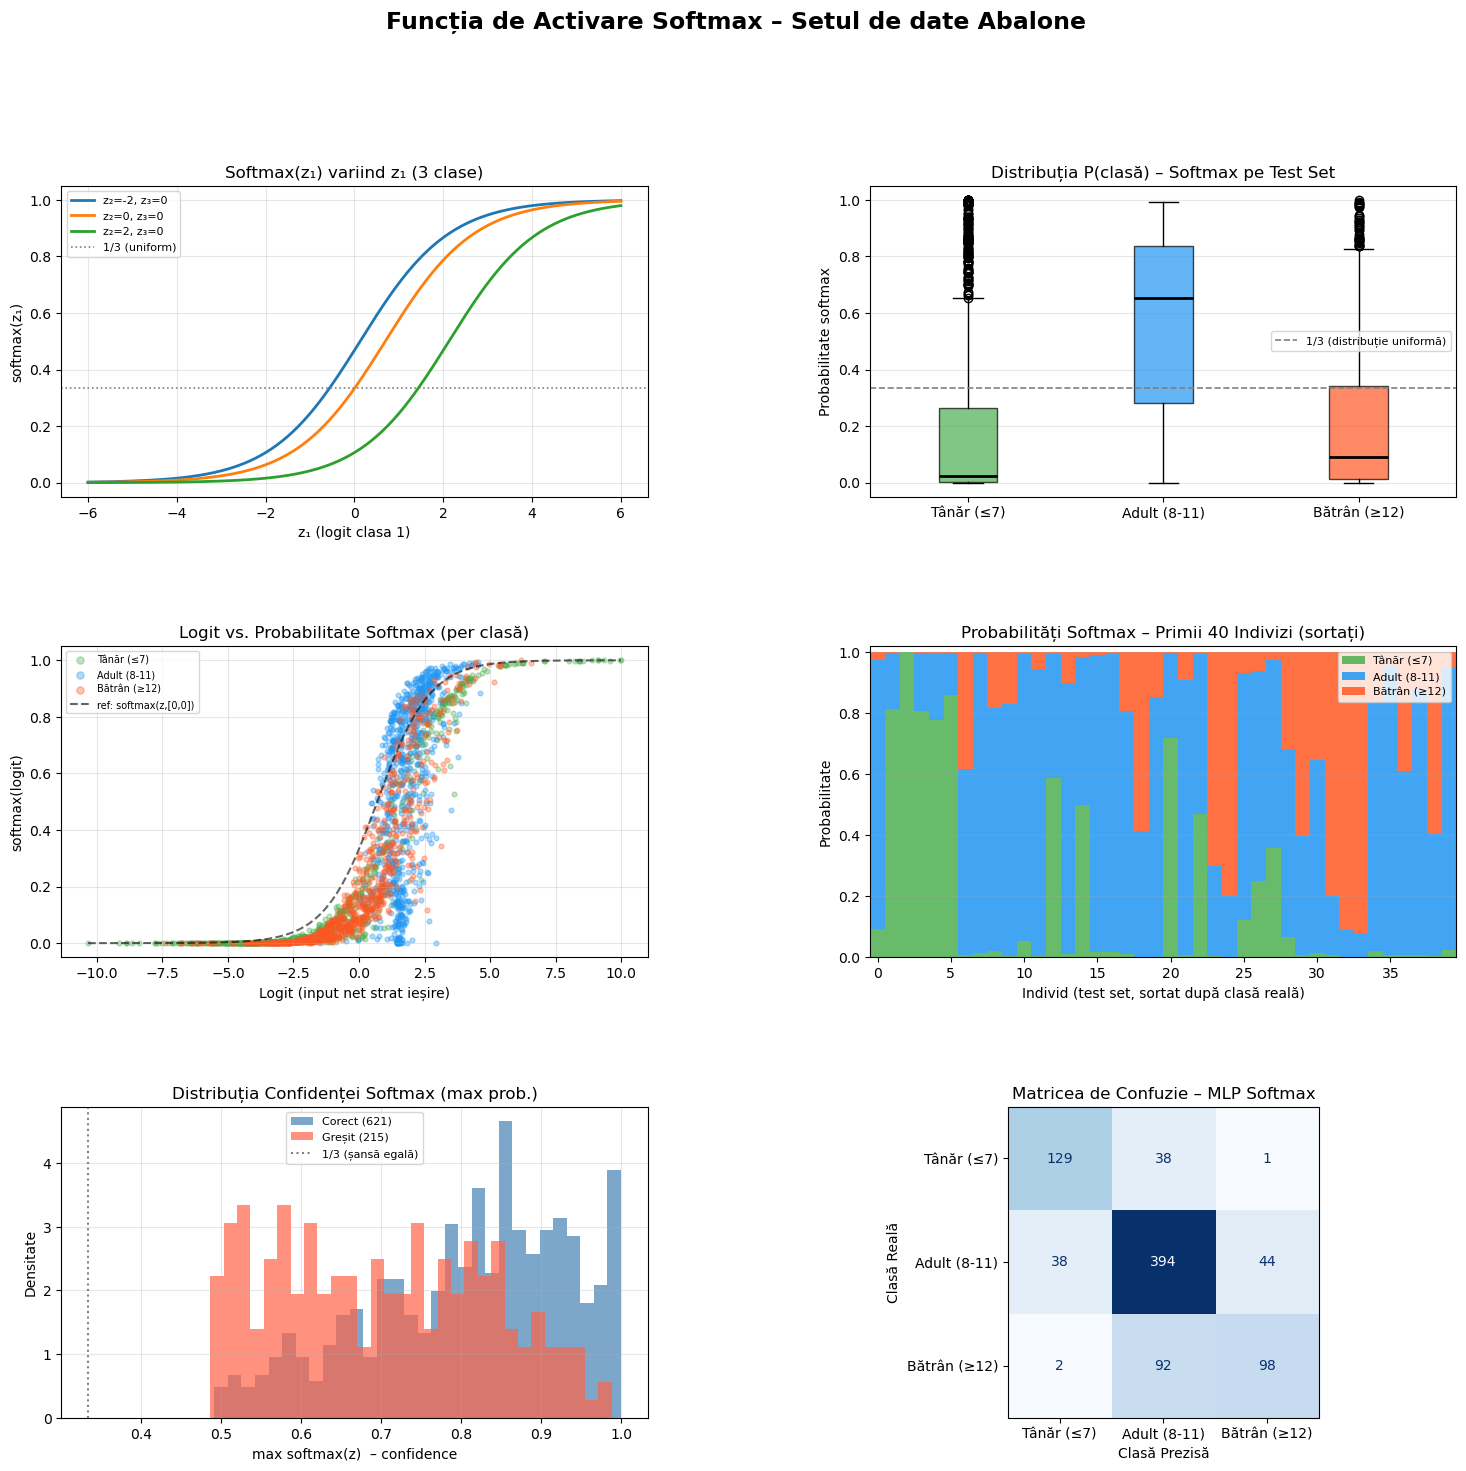

Graficul a fost salvat ca abalone_softmax.png


In [6]:
# ── 6. VIZUALIZARE PRINCIPALĂ – 6 subgrafice ──────────────────────────────────
fig = plt.figure(figsize=(18, 16))
fig.suptitle(
    'Funcția de Activare Softmax – Setul de date Abalone',
    fontsize=17, fontweight='bold', y=0.99
)
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.48, wspace=0.38)

# ──────────────────────────────────────────────────────────────────────────────
# (1,1) Softmax pe un vector 2D simplu – variind z1, z2 fix
# ──────────────────────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
z_sweep = np.linspace(-6, 6, 300)
z2_vals = [-2, 0, 2]
for z2_fix in z2_vals:
    sm_vals = np.array([softmax(np.array([z1, z2_fix, 0]))[0] for z1 in z_sweep])
    ax1.plot(z_sweep, sm_vals, lw=2, label=f'z₂={z2_fix}, z₃=0')
ax1.set_title('Softmax(z₁) variind z₁ (3 clase)', fontsize=12)
ax1.set_xlabel('z₁ (logit clasa 1)')
ax1.set_ylabel('softmax(z₁)')
ax1.axhline(1/3, color='gray', ls=':', lw=1.2, label='1/3 (uniform)')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(-0.05, 1.05)

# ──────────────────────────────────────────────────────────────────────────────
# (1,2) Distribuția probabilităților softmax pe setul de test – boxplot
# ──────────────────────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
bp = ax2.boxplot(
    [proba[:, k] for k in range(3)],
    labels=CLASS_NAMES,
    patch_artist=True,
    medianprops=dict(color='black', lw=2)
)
for patch, color in zip(bp['boxes'], COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax2.axhline(1/3, color='gray', ls='--', lw=1.2, label='1/3 (distribuție uniformă)')
ax2.set_title('Distribuția P(clasă) – Softmax pe Test Set', fontsize=12)
ax2.set_ylabel('Probabilitate softmax')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3, axis='y')

# ──────────────────────────────────────────────────────────────────────────────
# (2,1) Scatter logit vs probabilitate softmax pentru fiecare clasă
# ──────────────────────────────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
for k in range(3):
    ax3.scatter(logits[:, k], proba[:, k],
                c=COLORS[k], alpha=0.35, s=12, label=CLASS_NAMES[k])
z_th = np.linspace(logits.min(), logits.max(), 400)
# Curba de referință: softmax când ceilalți 2 logits = 0
sm_ref = np.array([softmax(np.array([z, 0, 0]))[0] for z in z_th])
ax3.plot(z_th, sm_ref, 'k--', lw=1.5, alpha=0.6, label='ref: softmax(z,[0,0])')
ax3.set_title('Logit vs. Probabilitate Softmax (per clasă)', fontsize=12)
ax3.set_xlabel('Logit (input net strat ieșire)')
ax3.set_ylabel('softmax(logit)')
ax3.legend(fontsize=7, markerscale=1.5)
ax3.grid(True, alpha=0.3)

# ──────────────────────────────────────────────────────────────────────────────
# (2,2) Stacked bar – primii 40 indivizi din test set
# ──────────────────────────────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
n_show = 40
idx_sort = np.argsort(y_test[:n_show])
p_show   = proba[:n_show][idx_sort]
x_pos    = np.arange(n_show)
bottom   = np.zeros(n_show)
for k in range(3):
    ax4.bar(x_pos, p_show[:, k], bottom=bottom,
            color=COLORS[k], alpha=0.85, label=CLASS_NAMES[k], width=1.0)
    bottom += p_show[:, k]
ax4.set_title(f'Probabilități Softmax – Primii {n_show} Indivizi (sortați)', fontsize=12)
ax4.set_xlabel('Individ (test set, sortat după clasă reală)')
ax4.set_ylabel('Probabilitate')
ax4.legend(fontsize=8, loc='upper right')
ax4.set_xlim(-0.5, n_show - 0.5)
ax4.set_ylim(0, 1.02)
ax4.grid(True, alpha=0.2, axis='y')

# ──────────────────────────────────────────────────────────────────────────────
# (3,1) Histograma probabilității maxime (confidence)
# ──────────────────────────────────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 0])
conf    = proba.max(axis=1)
correct = (mlp.predict(X_test) == y_test)
ax5.hist(conf[correct],  bins=30, color='steelblue', alpha=0.70,
         label=f'Corect ({correct.sum()})', density=True)
ax5.hist(conf[~correct], bins=30, color='tomato',    alpha=0.70,
         label=f'Greșit ({(~correct).sum()})', density=True)
ax5.axvline(1/3, color='gray', ls=':', lw=1.5, label='1/3 (șansă egală)')
ax5.set_title('Distribuția Confidenței Softmax (max prob.)', fontsize=12)
ax5.set_xlabel('max softmax(z)  – confidence')
ax5.set_ylabel('Densitate')
ax5.legend(fontsize=8)
ax5.grid(True, alpha=0.3)

# ──────────────────────────────────────────────────────────────────────────────
# (3,2) Matricea de confuzie
# ──────────────────────────────────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[2, 1])
cm = confusion_matrix(y_test, mlp.predict(X_test))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(ax=ax6, colorbar=False, cmap='Blues')
ax6.set_title('Matricea de Confuzie – MLP Softmax', fontsize=12)
ax6.set_xlabel('Clasă Prezisă')
ax6.set_ylabel('Clasă Reală')

plt.savefig('abalone_softmax.png', dpi=150, bbox_inches='tight')
plt.show()
print('Graficul a fost salvat ca abalone_softmax.png')

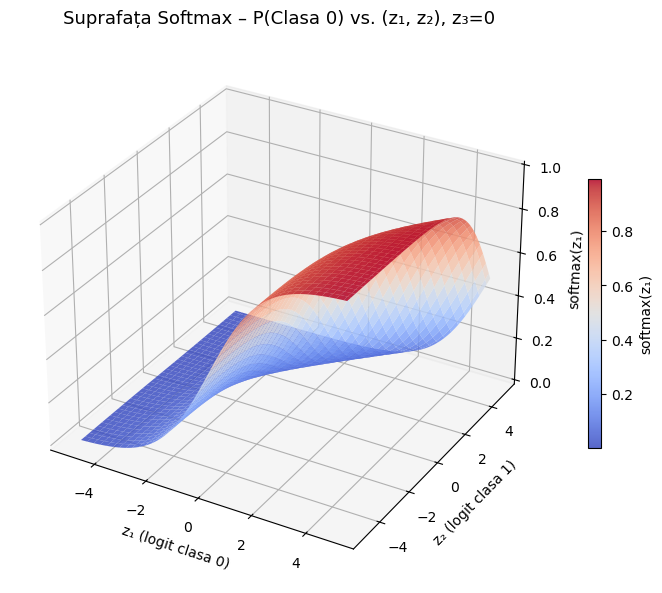

Graficul 3D a fost salvat ca abalone_softmax_3d.png


In [7]:
# ── 7. Vizualizare 3D – Suprafața Softmax în spațiul logit (z1, z2) ──────────
# Fixăm z3=0 și variăm z1, z2 pentru a vedea cum Softmax(z1) depinde de ambii
z1_vals = np.linspace(-5, 5, 80)
z2_vals = np.linspace(-5, 5, 80)
Z1, Z2  = np.meshgrid(z1_vals, z2_vals)

# Probabilitatea clasei 0 în funcție de (z1, z2), cu z3=0
SM0 = np.array([
    [softmax(np.array([z1, z2, 0]))[0] for z1 in z1_vals]
    for z2 in z2_vals
])

fig3d = plt.figure(figsize=(10, 7))
ax3d  = fig3d.add_subplot(111, projection='3d')
surf  = ax3d.plot_surface(Z1, Z2, SM0, cmap='coolwarm', alpha=0.85,
                           linewidth=0, antialiased=True)
fig3d.colorbar(surf, ax=ax3d, shrink=0.5, label='softmax(z₁)')
ax3d.set_title('Suprafața Softmax – P(Clasa 0) vs. (z₁, z₂), z₃=0',
               fontsize=13, pad=15)
ax3d.set_xlabel('z₁ (logit clasa 0)')
ax3d.set_ylabel('z₂ (logit clasa 1)')
ax3d.set_zlabel('softmax(z₁)')
ax3d.view_init(elev=30, azim=-60)

plt.savefig('abalone_softmax_3d.png', dpi=150, bbox_inches='tight')
plt.show()
print('Graficul 3D a fost salvat ca abalone_softmax_3d.png')

## Interpretarea graficelor

| Grafic | Descriere |
|--------|-----------|
| **Softmax(z₁) variind z₁** | Arată că probabilitatea unei clase crește monoton cu logit-ul ei, dar depinde și de ceilalți logits. |
| **Boxplot distribuție P(clasă)** | Distribuția probabilităților softmax pentru fiecare clasă pe setul de test. |
| **Logit vs. Probabilitate** | Relația non-liniară între logit și probabilitatea softmax, separată pe clase. |
| **Stacked bar (40 indivizi)** | Fiecare bară = un individ; înălțimile reprezintă distribuția de probabilitate softmax. |
| **Confidence (max prob.)** | Modelele cu confidence mare (aproape de 1) sunt mai sigure; eșantioanele greșit clasificate au confidence mai mică. |
| **Matricea de confuzie** | Evaluarea finală: câte eșantioane au fost clasificate corect/greșit per clasă. |
| **Suprafața 3D** | Vizualizare intuitivă a cum softmax(z₁) variază în funcție de doi logits simultan. |

### Proprietăți cheie ale Softmax
- **Sumă = 1**: output-ul este o distribuție de probabilitate validă.
- **Invariantă la translație**: softmax(z) = softmax(z + c) → numeric stabilă cu `z - max(z)`.
- **Sensibilă la diferențe**: dacă un logit este mult mai mare, probabilitatea lui domină (comportament *winner-takes-all*).
- **Legătură cu entropia încrucișată**: funcția de pierdere naturală asociată Softmax este *cross-entropy loss*.